# Understanding Token Embeddings

Language models cannot directly work with words or tokens.

For example:

```text
cat
dog
tree

A tokenizer first converts tokens into numerical IDs:

cat  → 0
dog  → 1
tree → 2

However, token IDs themselves do not carry meaning.

For example:

cat  → 0
dog  → 1
tree → 2

The numbers 0, 1, and 2 are simply indexes.

An embedding layer converts each token ID into a learnable vector:

cat
 ↓
0
 ↓
[0.2, -0.5, 0.8, 0.1]

The embedding vector is the representation that the Transformer processes.

The basic flow is:

Text
 ↓
Tokenizer
 ↓
Token IDs
 ↓
Embedding Layer
 ↓
Embedding Vectors
 ↓
Transformer

During training, the embedding vectors are updated along with the rest of the model.

This notebook explores:

How an embedding layer stores vectors
How token IDs retrieve embedding vectors
Why token IDs are not meaningful by themselves
How embeddings change during training
How embeddings connect to our Transformer model

```

In [2]:
import torch
import torch.nn as nn

token_to_id = {
    "cat": 0,
    "dog": 1,
    "tree": 2
}

id_to_token = {
    0: "cat",
    1: "dog",
    2: "tree"
}

print(token_to_id)

{'cat': 0, 'dog': 1, 'tree': 2}


In [3]:
embedding = nn.Embedding(
    num_embeddings= len(token_to_id),
    embedding_dim= 4
)

print(embedding)

Embedding(3, 4)


In [4]:
embedding.weight

Parameter containing:
tensor([[ 0.7364,  0.3019,  0.6816, -1.2617],
        [ 0.5209,  0.1509,  1.2051,  0.0403],
        [-0.5123, -1.2326,  0.0202,  0.4271]], requires_grad=True)

In [5]:
embedding.weight[0]

tensor([ 0.7364,  0.3019,  0.6816, -1.2617], grad_fn=<SelectBackward0>)

In [6]:
embedding(torch.tensor([0]))

tensor([[ 0.7364,  0.3019,  0.6816, -1.2617]], grad_fn=<EmbeddingBackward0>)

In [13]:
token_ids = torch.tensor([0, 1, 2])

vectors = embedding(token_ids)

print("Token IDs:")
print(token_ids)

print("\nVectors:")
print(vectors)

print("\nShape:")
print(vectors.shape)

Token IDs:
tensor([0, 1, 2])

Vectors:
tensor([[ 0.7364,  0.3019,  0.6816, -1.2617],
        [ 0.5209,  0.1509,  1.2051,  0.0403],
        [-0.5123, -1.2326,  0.0202,  0.4271]], grad_fn=<EmbeddingBackward0>)

Shape:
torch.Size([3, 4])


In [11]:
type(embedding)

torch.nn.modules.sparse.Embedding

In [15]:
torch.Tensor([0,1,2]).dtype

torch.float32

In [16]:
torch.tensor([0,1,2]).dtype

torch.int64

In [17]:
token_ids = torch.tensor([
    [0, 1, 2],
    [2, 1, 0]
])

print("Token IDs:")
print(token_ids)

print("\nShape:")
print(token_ids.shape)

Token IDs:
tensor([[0, 1, 2],
        [2, 1, 0]])

Shape:
torch.Size([2, 3])


In [18]:
vectors = embedding(token_ids)

print("\nEmbedded vectors:")
print(vectors)

print("\nShape:")
print(vectors.shape)


Embedded vectors:
tensor([[[ 0.7364,  0.3019,  0.6816, -1.2617],
         [ 0.5209,  0.1509,  1.2051,  0.0403],
         [-0.5123, -1.2326,  0.0202,  0.4271]],

        [[-0.5123, -1.2326,  0.0202,  0.4271],
         [ 0.5209,  0.1509,  1.2051,  0.0403],
         [ 0.7364,  0.3019,  0.6816, -1.2617]]], grad_fn=<EmbeddingBackward0>)

Shape:
torch.Size([2, 3, 4])


In [19]:
torch.manual_seed(42)

embedding = nn.Embedding(
    num_embeddings=3,
    embedding_dim=2
)

print("Initial embedding matrix:\n")
print(embedding.weight)

Initial embedding matrix:

Parameter containing:
tensor([[ 0.3367,  0.1288],
        [ 0.2345,  0.2303],
        [-1.1229, -0.1863]], requires_grad=True)


Matplotlib is building the font cache; this may take a moment.


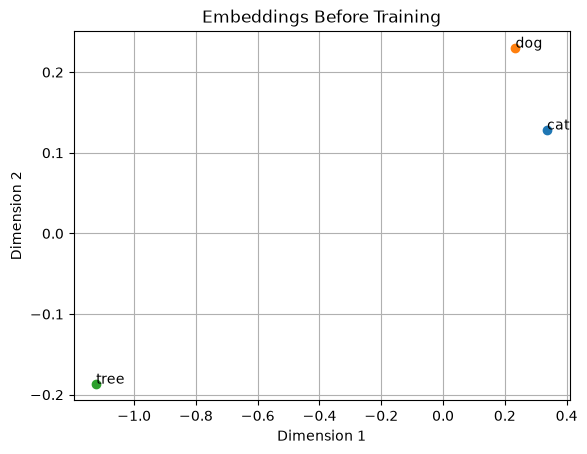

In [20]:
import matplotlib.pyplot as plt

tokens = ["cat", "dog", "tree"]

weights = embedding.weight.detach()

for i, token in enumerate(tokens):
    x = weights[i, 0]
    y = weights[i, 1]

    plt.scatter(x, y)
    plt.text(x, y, token)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Embeddings Before Training")

plt.grid()
plt.show()

In [21]:
optimizer = torch.optim.SGD(
    embedding.parameters(),
    lr=0.1
)

In [22]:
print(list(embedding.parameters()))

[Parameter containing:
tensor([[ 0.3367,  0.1288],
        [ 0.2345,  0.2303],
        [-1.1229, -0.1863]], requires_grad=True)]


In [23]:
cat_id = torch.tensor([0])
dog_id = torch.tensor([1])

cat_vector = embedding(cat_id)
dog_vector = embedding(dog_id)

print("Cat:")
print(cat_vector)

print("\nDog:")
print(dog_vector)

Cat:
tensor([[0.3367, 0.1288]], grad_fn=<EmbeddingBackward0>)

Dog:
tensor([[0.2345, 0.2303]], grad_fn=<EmbeddingBackward0>)


In [24]:
loss = ((cat_vector - dog_vector) ** 2).mean()

print("Loss:")
print(loss)

Loss:
tensor(0.0104, grad_fn=<MeanBackward0>)


In [27]:
loss.backward()

print(embedding.weight.grad)

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [28]:
print("Before update:")
print(embedding.weight)

Before update:
Parameter containing:
tensor([[ 0.3367,  0.1288],
        [ 0.2345,  0.2303],
        [-1.1229, -0.1863]], requires_grad=True)


In [29]:
optimizer.step()

print("\nAfter update:")
print(embedding.weight)


After update:
Parameter containing:
tensor([[ 0.3265,  0.1390],
        [ 0.2447,  0.2202],
        [-1.1229, -0.1863]], requires_grad=True)


In [30]:
print("Gradients:")
print(embedding.weight.grad)

Gradients:
tensor([[ 0.1022, -0.1015],
        [-0.1022,  0.1015],
        [ 0.0000,  0.0000]])


Vocabulary size: 12
Token IDs: {'cat': 0, 'dog': 1, 'lion': 2, 'tiger': 3, 'tree': 4, 'rose': 5, 'grass': 6, 'flower': 7, 'apple': 8, 'banana': 9, 'orange': 10, 'mango': 11}

Number of training pairs: 36

--- First training step ---
Embedding before update: tensor([1.9269, 1.4873])
Gradient for embedding row: tensor([-0.0092, -0.0035])
Embedding after update: tensor([1.9769, 1.5373])
Step    0 | Loss: 2.4992
Step  200 | Loss: 1.3005
Step  400 | Loss: 1.2778
Step  600 | Loss: 1.2648
Step  800 | Loss: 1.2580

Embedding positions before training:
cat      [1.9269150495529175, 1.4872841835021973]
dog      [0.9007171988487244, -2.1055214405059814]
lion     [0.6784184575080872, -1.2345449924468994]
tiger    [-0.043067481368780136, -1.6046669483184814]
tree     [0.35585978627204895, -0.6866229772567749]
rose     [-0.4933563470840454, 0.2414878010749817]
grass    [-1.1109040975570679, 0.09154565632343292]
flower   [-2.316922664642334, -0.21680472791194916]
apple    [-0.30972692370414734, -0.39

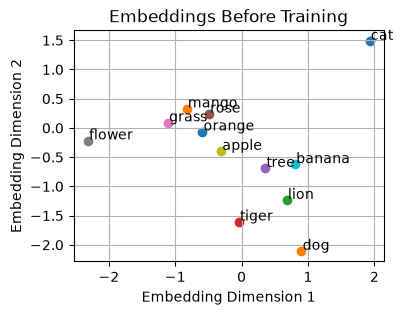

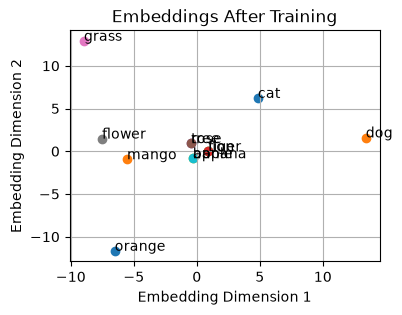


Example learned predictions:
cat      → ['lion', 'tiger', 'dog', 'flower']
tree     → ['flower', 'rose', 'tree', 'grass']
apple    → ['mango', 'banana', 'apple', 'orange']


In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ============================================================
# 1. Small vocabulary
# ============================================================

tokens = [
    "cat", "dog", "lion", "tiger",
    "tree", "rose", "grass", "flower",
    "apple", "banana", "orange", "mango"
]

token_to_id = {
    token: idx
    for idx, token in enumerate(tokens)
}

vocab_size = len(tokens)
embedding_dim = 2

print("Vocabulary size:", vocab_size)
print("Token IDs:", token_to_id)


# ============================================================
# 2. Training examples
#
# Each pair means:
#   given the first token,
#   predict the second token as a related/context word.
#
# This is a tiny Word2Vec-style learning setup.
# ============================================================

pairs = [
    # Animals occur together
    ("cat", "dog"),
    ("cat", "lion"),
    ("cat", "tiger"),
    ("dog", "cat"),
    ("dog", "lion"),
    ("dog", "tiger"),
    ("lion", "cat"),
    ("lion", "dog"),
    ("lion", "tiger"),
    ("tiger", "cat"),
    ("tiger", "dog"),
    ("tiger", "lion"),

    # Plants occur together
    ("tree", "rose"),
    ("tree", "grass"),
    ("tree", "flower"),
    ("rose", "tree"),
    ("rose", "grass"),
    ("rose", "flower"),
    ("grass", "tree"),
    ("grass", "rose"),
    ("grass", "flower"),
    ("flower", "tree"),
    ("flower", "rose"),
    ("flower", "grass"),

    # Fruits occur together
    ("apple", "banana"),
    ("apple", "orange"),
    ("apple", "mango"),
    ("banana", "apple"),
    ("banana", "orange"),
    ("banana", "mango"),
    ("orange", "apple"),
    ("orange", "banana"),
    ("orange", "mango"),
    ("mango", "apple"),
    ("mango", "banana"),
    ("mango", "orange"),
]

inputs = torch.tensor([
    token_to_id[token]
    for token, context in pairs
])

targets = torch.tensor([
    token_to_id[context]
    for token, context in pairs
])

print("\nNumber of training pairs:", len(pairs))


# ============================================================
# 3. Embedding + very small prediction model
#
# input token ID
#      ↓
# input embedding
#      ↓
# linear projection
#      ↓
# scores for every possible context token
# ============================================================

embedding = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=embedding_dim
)

output_layer = nn.Linear(
    embedding_dim,
    vocab_size,
    bias=False
)

model_parameters = list(embedding.parameters()) + list(
    output_layer.parameters()
)

optimizer = torch.optim.Adam(
    model_parameters,
    lr=0.05
)

loss_fn = nn.CrossEntropyLoss()


# ============================================================
# 4. Save the initial embedding positions
# ============================================================

initial_embeddings = embedding.weight.detach().clone()

watch_token = "cat"
watch_id = token_to_id[watch_token]
initial_watch_embedding = embedding.weight[watch_id].detach().clone()

# ============================================================
# 5. Training loop
#
# The embedding is NOT directly told:
# "cat should be near dog".
#
# Instead:
# token → embedding → prediction → loss
#                                ↓
#                         backward()
#                                ↓
#                         embedding changes
# ============================================================

for step in range(1000):

    # Look up embeddings for the input tokens
    input_vectors = embedding(inputs)

    # Predict the context token
    logits = output_layer(input_vectors)

    # Compare prediction with the actual context token
    loss = loss_fn(logits, targets)

    # # Calculate gradients
    # optimizer.zero_grad()
    # loss.backward()

    # # Update embedding and output-layer weights
    # optimizer.step()

    optimizer.zero_grad()
    loss.backward()

    if step == 0:
        print("\n--- First training step ---")
        print("Embedding before update:", embedding.weight[watch_id].detach())
        print("Gradient for embedding row:", embedding.weight.grad[watch_id].detach())

    optimizer.step()

    if step == 0:
        print("Embedding after update:", embedding.weight[watch_id].detach())

    if step % 200 == 0:
        print(f"Step {step:4d} | Loss: {loss.item():.4f}")


# ============================================================
# 6. Save final embedding positions
# ============================================================

final_embeddings = embedding.weight.detach().clone()


# ============================================================
# 7. Inspect a few embeddings before and after
# ============================================================

print("\nEmbedding positions before training:")
for i, token in enumerate(tokens):
    print(f"{token:8s} {initial_embeddings[i].tolist()}")

print("\nEmbedding positions after training:")
for i, token in enumerate(tokens):
    print(f"{token:8s} {final_embeddings[i].tolist()}")


# ============================================================
# 8. Visualize BEFORE training
# ============================================================

plt.figure(figsize=(4, 3))

for i, token in enumerate(tokens):
    x = initial_embeddings[i, 0].item()
    y = initial_embeddings[i, 1].item()

    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, token)

plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.title("Embeddings Before Training")
plt.grid()

plt.show()


# ============================================================
# 9. Visualize AFTER training
# ============================================================

plt.figure(figsize=(4, 3))

for i, token in enumerate(tokens):
    x = final_embeddings[i, 0].item()
    y = final_embeddings[i, 1].item()

    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, token)

plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.title("Embeddings After Training")
plt.grid()

plt.show()


# ============================================================
# 10. Check a few predictions
# ============================================================

test_tokens = ["cat", "tree", "apple"]

print("\nExample learned predictions:")

with torch.no_grad():

    for token in test_tokens:
        token_id = torch.tensor([token_to_id[token]])

        vector = embedding(token_id)
        logits = output_layer(vector)

        probabilities = F.softmax(logits, dim=-1)

        top_ids = torch.topk(
            probabilities,
            k=4,
            dim=-1
        ).indices[0]

        predictions = [
            tokens[idx]
            for idx in top_ids
        ]

        print(f"{token:8s} → {predictions}")

# Embeddings — Final Summary

An embedding layer converts discrete **token IDs** into dense, learned vectors.

For a vocabulary of size `V` and embedding dimension `D`, the embedding table has shape:

$$
E \in \mathbb{R}^{V \times D}
$$

Each token ID selects one row:

$$
\text{embedding}(token\_id) = E[token\_id]
$$

For example, if:

```text
cat → 5
```

then:

```python
embedding.weight[5]
```

is the learned vector representing the token `cat`.

## How embeddings learn

The embedding table does not learn by itself. In a normal language model, it is trained as part of the complete model:

```text
Token IDs
   ↓
Embedding lookup
   ↓
Transformer
   ↓
Logits
   ↓
Loss
   ↓
Backpropagation
   ↓
Gradients
   ↓
Optimizer update
```

The gradient flows all the way back to the embedding table, so the specific rows used by the training example can be updated.

For a token with ID `5`, we can inspect:

```python
embedding.weight[5]
embedding.weight.grad[5]
```

before and after `optimizer.step()` to directly see the update.

## How this differs from our toy experiment

In our small experiment, we manually created relationships such as:

```text
cat   → dog, lion, tiger
tree  → rose, grass, flower
apple → banana, orange, mango
```

This made the learning signal easy to understand and visualize.

A real LLM does **not** manually receive these semantic relationships.

Instead, it trains on large amounts of natural text using a next-token prediction objective:

```text
"The cat chased the" → "dog"
"The dog slept near the" → "tree"
```

Across a huge corpus, these repeated prediction tasks create gradients that gradually shape the embedding table and the rest of the model.

Therefore, semantic structure can emerge without explicitly telling the model which words should be close.

## Embedding vs contextual representation

The input embedding is only the **initial representation** of a token.

The same token starts with the same embedding regardless of context:

```text
"The bank approved the loan."
"The river bank was flooded."
```

But after passing through the Transformer, attention and feed-forward layers incorporate surrounding tokens, producing different **contextual representations**.

So:

```text
Embedding
→ initial token representation

Transformer
→ contextual representation
```

This is why an LLM's understanding is not contained in a single embedding vector.

## Main takeaway

The embedding layer is a learned lookup table. Token IDs select rows from it, and those rows are updated through the normal forward → loss → backward → optimizer training process.

In a real LLM, we do not explicitly tell the model that words are related. Large-scale language data and the next-token prediction objective provide the learning signal from which useful representations and relationships emerge.

The embedding layer is therefore the **starting representation**, while the Transformer builds the richer contextual representation used for prediction.